In [1]:
# Install required libraries

!pip install pymatgen shap scikit-learn xgboost

In [2]:
# Import core libraries for data handling, ML, and feature extraction

import pandas as pd
import numpy as np
import os

# ML
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, roc_auc_score

# Encoding
from sklearn.preprocessing import StandardScaler

# Interpretability
import shap

# Materials science
from pymatgen.core import Structure

In [3]:
# Mount Google Drive
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [4]:
# Load dataset (make sure Dataset.csv is in /content/Project/)

data_path = "/content/drive/MyDrive/Project/Dataset.csv"
df = pd.read_csv(data_path)

# Quick check
print(df.shape)
df.head()

(7000, 17)


,mp_material_id,mp_formula,spacegroup,spacegroup_number,number of atoms,Band Gap,a,b,c,alpha,beta,gamma,Z,electronegativity,Topological Label,label,cif
0,mp-331,ScAl,Pm3m,221,2.0,0.0000,3.370349,3.370349,3.370349,90.000000,90.000000,90.000000,1.0,1.485,TI,1,cif_files/mp-331.cif
1,mp-698479,RbTeHOF4,Cc,9,32.0,4.8825,8.430517,8.430517,14.075609,85.886490,85.886490,34.382176,6.4,3.060,Trivial,0,cif_files/mp-698479.cif
2,mp-549237,Sr2Fe2S2OF2,I4/mmm,139,18.0,1.4677,4.095118,4.096245,18.221803,90.002343,90.003680,89.993481,3.6,2.458,Trivial,0,cif_files/mp-549237.cif
3,mp-13089,Cu2SnTe3,Imm2,44,6.0,0.0000,4.409910,6.113668,7.554224,113.869340,106.970766,90.000000,1.0,2.010,Trivial,0,cif_files/mp-13089.cif
4,mp-10732,ThTaN3,Pm-3m,221,5.0,0.0766,4.064437,4.064437,4.064437,90.000000,90.000000,90.000000,1.0,2.384,Topological,1,cif_files/mp-10732.cif


In [5]:
# Drop columns that do not contribute to learning

df = df.drop(columns=[
    'mp_material_id',   # identifier (no predictive value)
    'mp_formula',       # string (not directly usable)
    'Topological Label' # duplicate of label
])

# Ensure label is integer
df['label'] = df['label'].astype(int)

# Check class balance
print(df['label'].value_counts())

label
0    3536
1    3464
Name: count, dtype: int64


In [ ]:
import os
import numpy as np
import pandas as pd
from pymatgen.core import Structure
from tqdm import tqdm

# Base path to CIF files
base_path = "/content/drive/MyDrive/Project/"

# Robust feature extraction function
def extract_features(cif_path):
    try:
        full_path = os.path.join(base_path, cif_path)
        structure = Structure.from_file(full_path)

        # --- Structural features ---
        volume = structure.volume
        density = structure.density
        num_atoms = len(structure)

        # --- Atomic features ---
        elements = [site.specie for site in structure]

        atomic_numbers = [el.Z for el in elements]
        avg_Z = np.mean(atomic_numbers)

        atomic_masses = [el.atomic_mass for el in elements]
        mean_mass = np.mean(atomic_masses)

        # Handle missing electronegativity safely
        enegs = [el.X for el in elements if el.X is not None]
        mean_eneg = np.mean(enegs) if len(enegs) > 0 else np.nan

        return pd.Series([
            volume,
            density,
            num_atoms,
            avg_Z,
            mean_mass,
            mean_eneg
        ])

    except Exception as e:
        print(f"Error processing {cif_path}: {e}")
        return pd.Series([np.nan] * 6)


# Enable progress bar
tqdm.pandas()

# Apply feature extraction
df[['volume',
    'density',
    'num_atoms',
    'avg_Z',
    'mean_mass',
    'mean_eneg']] = df['cif'].progress_apply(extract_features)

# Drop failed rows
df = df.dropna().reset_index(drop=True)

print("✅ Feature extraction complete.")
print(f"Final dataset size: {df.shape}")

  0%|          | 25/7000 [00:08<43:08,  2.70it/s]/usr/local/lib/python3.12/dist-packages/pymatgen/core/structure.py:3112: UserWarning: Issues encountered while parsing CIF: 4 fractional coordinates rounded to ideal values to avoid issues with finite precision.
  struct = parser.parse_structures(primitive=primitive)[0]
  1%|          | 45/7000 [00:16<40:30,  2.86it/s]/usr/local/lib/python3.12/dist-packages/pymatgen/core/structure.py:3112: UserWarning: Issues encountered while parsing CIF: 8 fractional coordinates rounded to ideal values to avoid issues with finite precision.
  struct = parser.parse_structures(primitive=primitive)[0]
  1%|          | 85/7000 [00:30<43:58,  2.62it/s]/usr/local/lib/python3.12/dist-packages/pymatgen/core/structure.py:3112: UserWarning: Issues encountered while parsing CIF: 6 fractional coordinates rounded to ideal values to avoid issues with finite precision.
  struct = parser.parse_structures(primitive=primitive)[0]
  1%|▏         | 93/7000 [00:33<38:57,  

✅ Feature extraction complete.
Final dataset size: (7000, 20)


In [ ]:
# Instead of raw spacegroup numbers, normalize them
# Reason: avoid artificial ordering bias

df['spacegroup_number'] = df['spacegroup_number'] / 230.0

In [ ]:
# Define input features
X = df.drop(columns=['label', 'cif', 'spacegroup'])
y = df['label']

print("Feature shape:", X.shape)

Feature shape: (7000, 17)


In [ ]:
# First split: train (70%) vs temp (30%)

X_train, X_temp, y_train, y_temp = train_test_split(
    X, y, test_size=0.30, random_state=42, stratify=y
)

# Second split: validation (15%) and test (15%)

X_val, X_test, y_val, y_test = train_test_split(
    X_temp, y_temp, test_size=0.50, random_state=42, stratify=y_temp
)

print("Train:", X_train.shape)
print("Val:", X_val.shape)
print("Test:", X_test.shape)

Train: (4900, 17)
Val: (1050, 17)
Test: (1050, 17)


In [ ]:
# Random Forest model
# n_estimators=500 (good bias-variance tradeoff)
# random_state ensures reproducibility

rf_model = RandomForestClassifier(
    n_estimators=500,
    max_depth=None,
    random_state=42,
    n_jobs=-1
)

rf_model.fit(X_train, y_train)

RandomForestClassifier(n_estimators=500, n_jobs=-1, random_state=42)

In [ ]:
# Predictions

y_pred = rf_model.predict(X_test)
y_prob = rf_model.predict_proba(X_test)[:, 1]

# Metrics

accuracy = accuracy_score(y_test, y_pred)
precision = precision_score(y_test, y_pred)
recall = recall_score(y_test, y_pred)
f1 = f1_score(y_test, y_pred)
roc_auc = roc_auc_score(y_test, y_prob)

print(f"Accuracy: {accuracy:.4f}")
print(f"Precision: {precision:.4f}")
print(f"Recall: {recall:.4f}")
print(f"F1 Score: {f1:.4f}")
print(f"ROC-AUC: {roc_auc:.4f}")

Accuracy: 0.8524
Precision: 0.8625
Recall: 0.8343
F1 Score: 0.8482
ROC-AUC: 0.9375


In [ ]:
# SHAP explains which features drive predictions

explainer = shap.TreeExplainer(rf_model)
shap_values = explainer.shap_values(X_test)

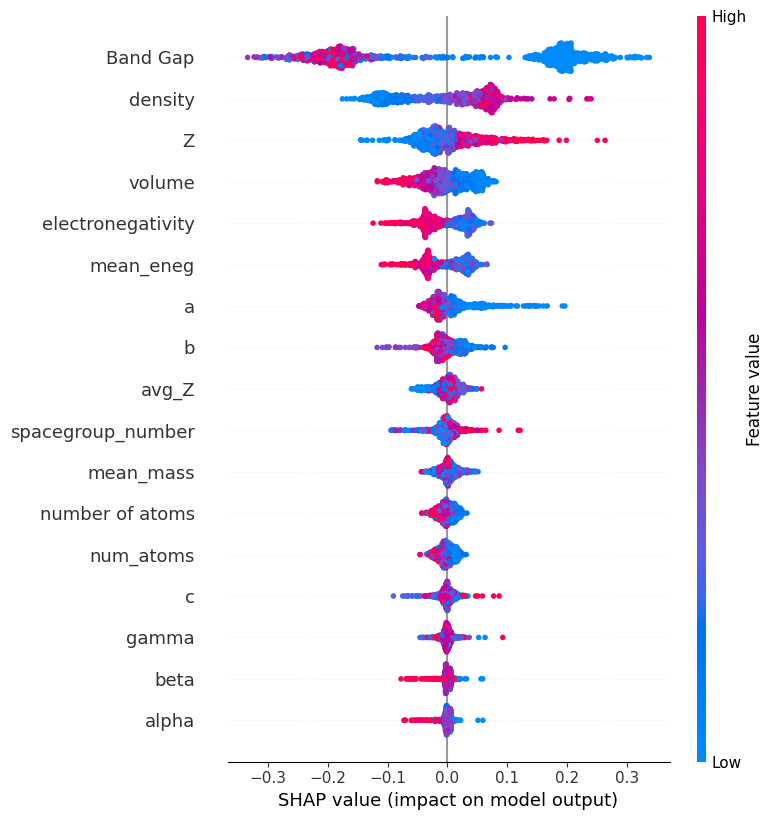

In [ ]:
shap.summary_plot(shap_values[:, :, 1], X_test)

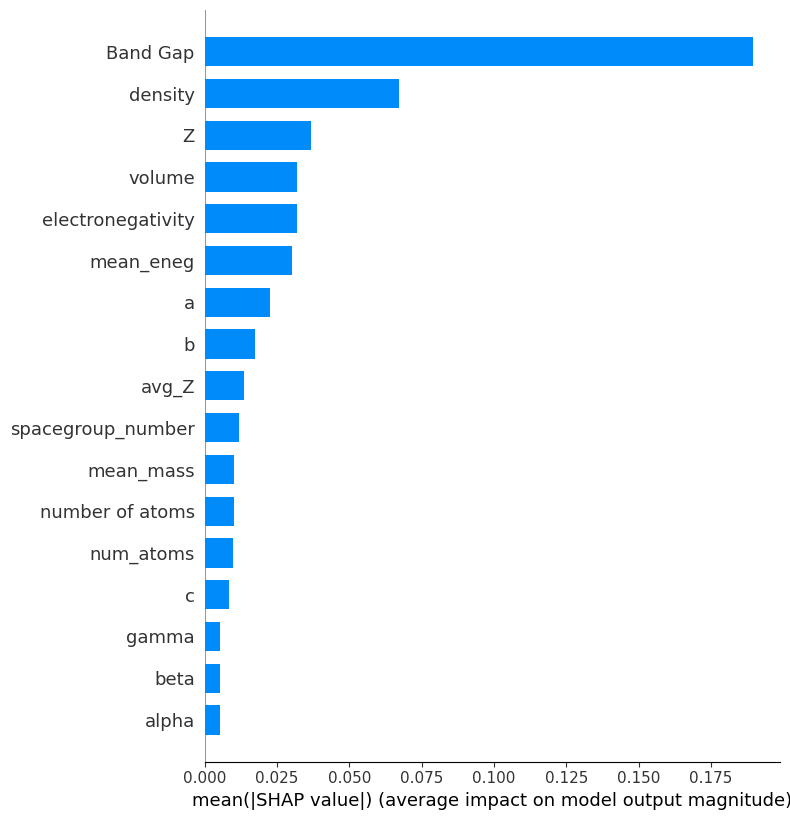

In [ ]:
shap.summary_plot(shap_values[:, :, 1], X_test, plot_type="bar")

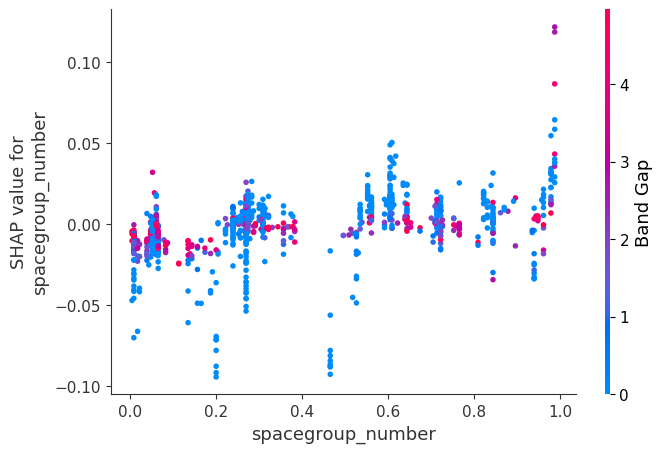

In [ ]:
# Example: choose most important feature manually if needed
shap.dependence_plot(X_test.columns[0], shap_values[:, :, 1], X_test)

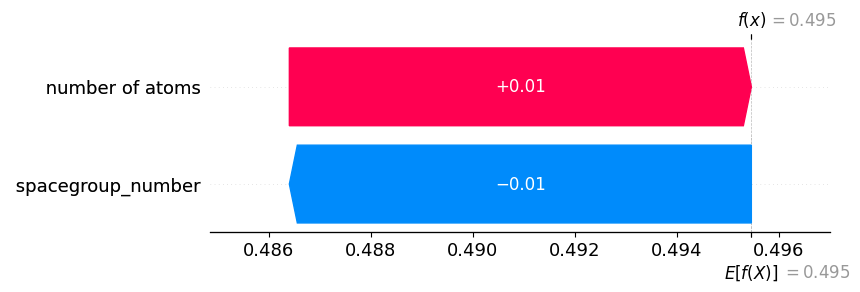

In [ ]:
shap.plots._waterfall.waterfall_legacy(
    explainer.expected_value[1],
    shap_values[1][0],
    X_test.iloc[0]
)

In [ ]:
shap.initjs()
shap.force_plot(
    explainer.expected_value[1],
    shap_values[0, :, 1],
    X_test.iloc[0]
)

In [ ]:
# Install XGBoost

!pip install xgboost shap

In [ ]:
# Import libraries

import xgboost as xgb

from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, roc_auc_score
import shap

In [ ]:
# Reuse processed dataset from RF step

# X_train, X_val, X_test, y_train, y_val, y_test already defined

print("Train:", X_train.shape)
print("Validation:", X_val.shape)
print("Test:", X_test.shape)

Train: (4900, 17)
Validation: (1050, 17)
Test: (1050, 17)


In [ ]:
# XGBoost classifier
# Parameters chosen based on common practice in literature

xgb_model = xgb.XGBClassifier(
    n_estimators=500,        # number of trees (similar reasoning as RF)
    max_depth=6,             # controls complexity (prevents overfitting)
    learning_rate=0.05,      # smaller step size → better generalization
    subsample=0.8,           # stochastic boosting (reduces overfitting)
    colsample_bytree=0.8,    # feature sampling per tree
    random_state=42,
    use_label_encoder=False,
    eval_metric='logloss'    # standard for binary classification
)

# Train with validation monitoring
xgb_model.fit(
    X_train, y_train,
    eval_set=[(X_val, y_val)],
    verbose=True
)

[0]	validation_0-logloss:0.66734
[1]	validation_0-logloss:0.64405


/usr/local/lib/python3.12/dist-packages/xgboost/training.py:200: UserWarning: [12:16:19] WARNING: /__w/xgboost/xgboost/src/learner.cc:782: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)


[2]	validation_0-logloss:0.62286
[3]	validation_0-logloss:0.60369
[4]	validation_0-logloss:0.58939
[5]	validation_0-logloss:0.57263
[6]	validation_0-logloss:0.55709
[7]	validation_0-logloss:0.54252
[8]	validation_0-logloss:0.53254
[9]	validation_0-logloss:0.52001
[10]	validation_0-logloss:0.50802
[11]	validation_0-logloss:0.49953
[12]	validation_0-logloss:0.48922
[13]	validation_0-logloss:0.48012
[14]	validation_0-logloss:0.47054
[15]	validation_0-logloss:0.46428
[16]	validation_0-logloss:0.45805
[17]	validation_0-logloss:0.45085
[18]	validation_0-logloss:0.44284
[19]	validation_0-logloss:0.43638
[20]	validation_0-logloss:0.43103
[21]	validation_0-logloss:0.42416
[22]	validation_0-logloss:0.41847
[23]	validation_0-logloss:0.41311
[24]	validation_0-logloss:0.40729
[25]	validation_0-logloss:0.40203
[26]	validation_0-logloss:0.39835
[27]	validation_0-logloss:0.39484
[28]	validation_0-logloss:0.39018
[29]	validation_0-logloss:0.38688
[30]	validation_0-logloss:0.38398
[31]	validation_0-logl

XGBClassifier(base_score=None, booster=None, callbacks=None,
              colsample_bylevel=None, colsample_bynode=None,
              colsample_bytree=0.8, device=None, early_stopping_rounds=None,
              enable_categorical=False, eval_metric='logloss',
              feature_types=None, feature_weights=None, gamma=None,
              grow_policy=None, importance_type=None,
              interaction_constraints=None, learning_rate=0.05, max_bin=None,
              max_cat_threshold=None, max_cat_to_onehot=None,
              max_delta_step=None, max_depth=6, max_leaves=None,
              min_child_weight=None, missing=nan, monotone_constraints=None,
              multi_strategy=None, n_estimators=500, n_jobs=None,
              num_parallel_tree=None, ...)

In [ ]:
# Predictions

y_pred = xgb_model.predict(X_test)
y_prob = xgb_model.predict_proba(X_test)[:, 1]

# Metrics

accuracy = accuracy_score(y_test, y_pred)
precision = precision_score(y_test, y_pred)
recall = recall_score(y_test, y_pred)
f1 = f1_score(y_test, y_pred)
roc_auc = roc_auc_score(y_test, y_prob)

print(f"Accuracy: {accuracy:.4f}")
print(f"Precision: {precision:.4f}")
print(f"Recall: {recall:.4f}")
print(f"F1 Score: {f1:.4f}")
print(f"ROC-AUC: {roc_auc:.4f}")

Accuracy: 0.8695
Precision: 0.8716
Recall: 0.8632
F1 Score: 0.8674
ROC-AUC: 0.9442


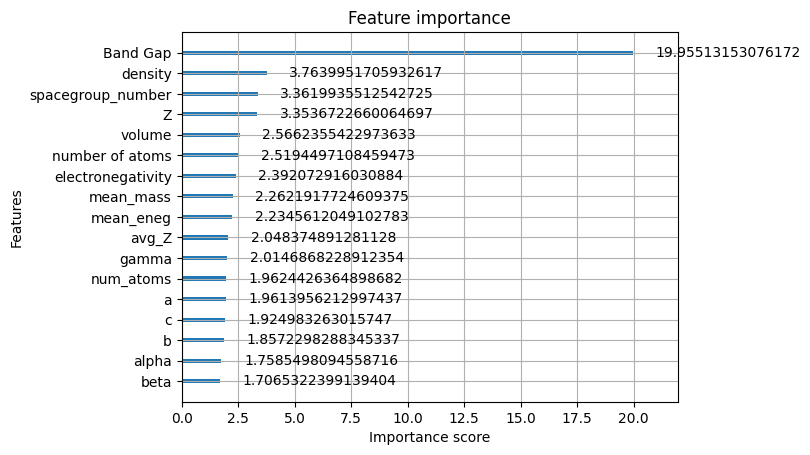

In [ ]:
# Built-in importance (gain-based)

import matplotlib.pyplot as plt

xgb.plot_importance(xgb_model, importance_type='gain')
plt.show()

In [ ]:
# SHAP Explainer for XGBoost

explainer = shap.TreeExplainer(xgb_model)
shap_values = explainer.shap_values(X_test)

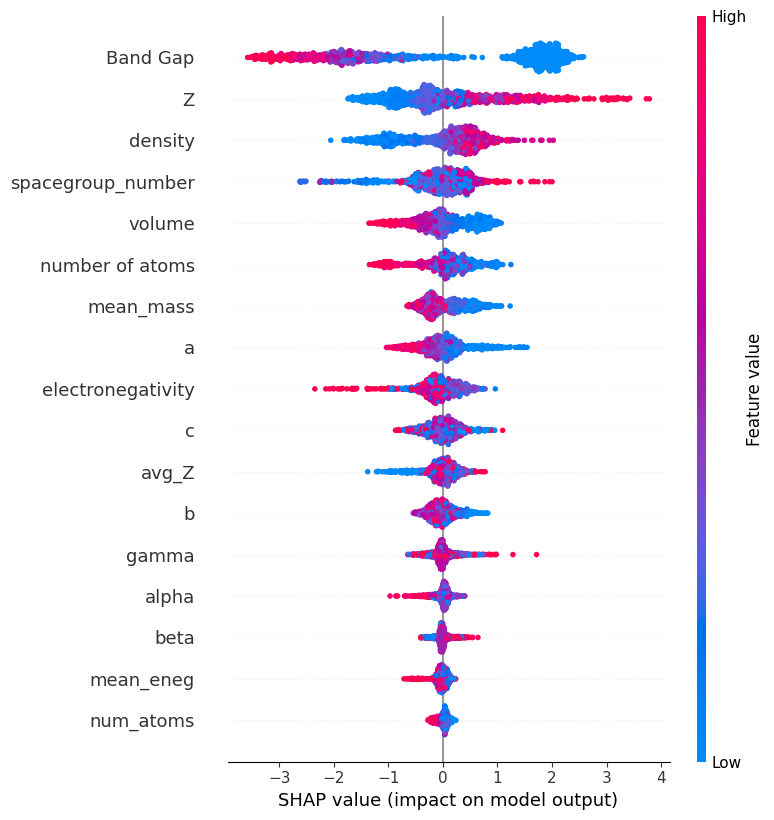

In [ ]:
shap.summary_plot(shap_values, X_test)

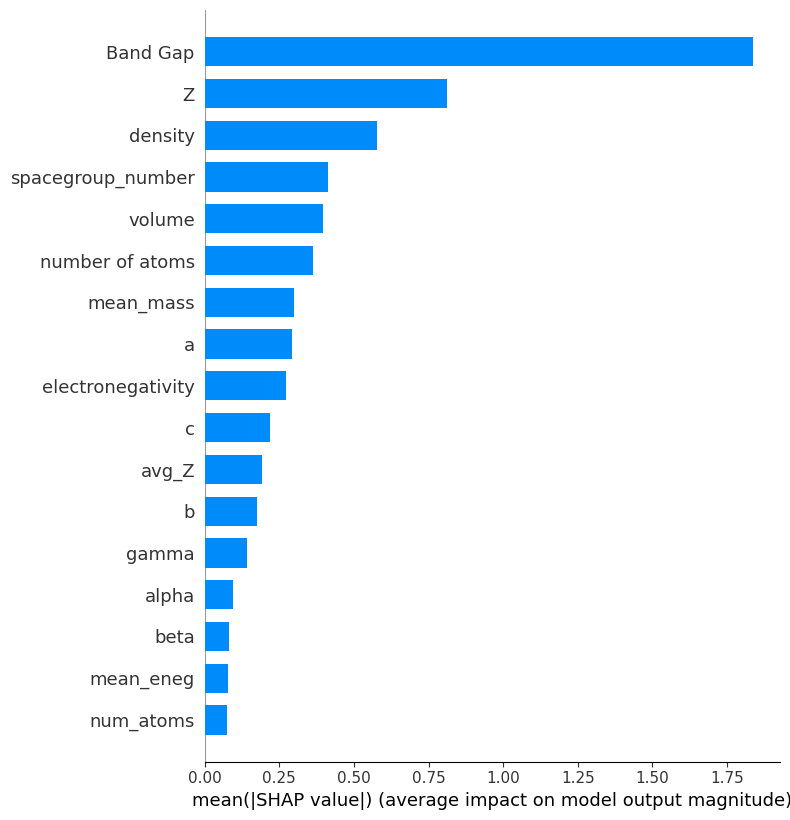

In [ ]:
shap.summary_plot(shap_values, X_test, plot_type="bar")

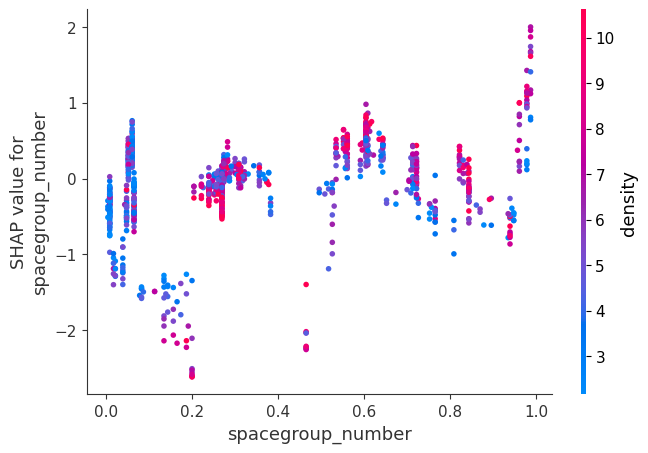

In [ ]:
# Replace with most important feature if needed
shap.dependence_plot(X_test.columns[0], shap_values, X_test)

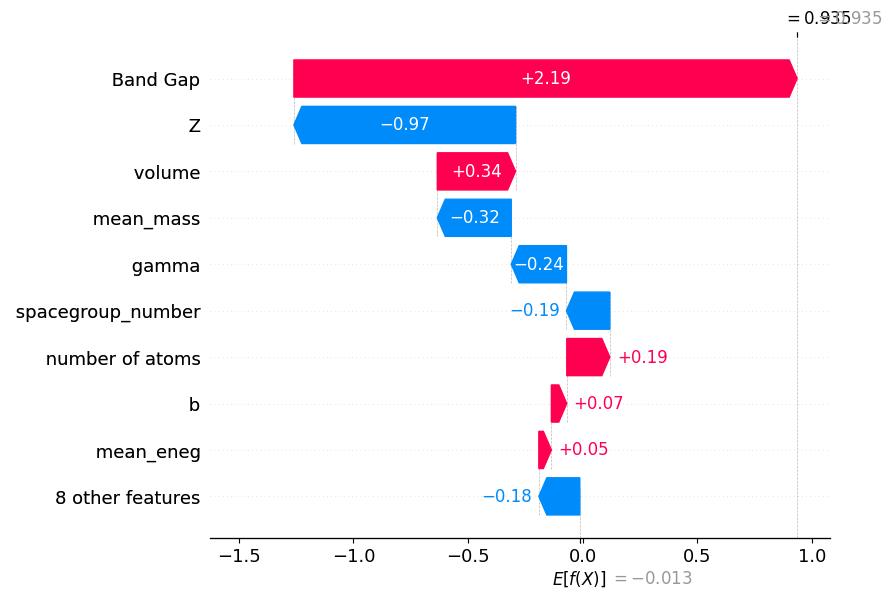

In [ ]:
shap.plots._waterfall.waterfall_legacy(
    explainer.expected_value,
    shap_values[0],
    X_test.iloc[0]
)

In [ ]:
# Install PyTorch Geometric (for graph neural networks)
# and pymatgen for structure parsing

!pip install torch-geometric pymatgen

  Using cached torch_geometric-2.7.0-py3-none-any.whl.metadata (63 kB)
Using cached torch_geometric-2.7.0-py3-none-any.whl (1.3 MB)


In [ ]:
# Core imports

import torch
from torch_geometric.data import Data
from torch_geometric.data import Dataset, DataLoader
import pandas as pd
import numpy as np
import os

from pymatgen.core import Structure

In [ ]:
# Core imports

import torch
from torch_geometric.data import Data
from torch_geometric.data import Dataset, DataLoader
import pandas as pd
import numpy as np
import os

from pymatgen.core import Structure

In [ ]:
# Convert distances into feature vectors (used in CGCNN paper)

def gaussian_distance(distances, centers, width=0.5):
    return np.exp(-(distances[..., np.newaxis] - centers)**2 / width**2)

In [ ]:
# This is the MOST important part
# Converts CIF → graph

def build_graph(cif_path, global_features):

    structure = Structure.from_file(cif_path)

    # Node features
    node_features = []
    for site in structure:
        Z = site.specie.Z
        node_features.append([Z])

    node_features = torch.tensor(node_features, dtype=torch.float)

    # Edge construction (cutoff = 6 Å)
    cutoff = 6.0
    edge_index = []
    edge_attr = []

    centers = np.linspace(0, cutoff, 50)

    for i, site_i in enumerate(structure):
        neighbors = structure.get_neighbors(site_i, cutoff)

        for neighbor in neighbors:
            j = neighbor.index
            dist = neighbor.nn_distance

            edge_index.append([i, j])

            # Gaussian expanded distance
            edge_feat = gaussian_distance(dist, centers)
            edge_attr.append(edge_feat.flatten())

    edge_index = torch.tensor(edge_index, dtype=torch.long).t().contiguous()
    edge_attr = torch.tensor(edge_attr, dtype=torch.float)

    # Global features (from CSV)
    u = torch.tensor(global_features, dtype=torch.float).unsqueeze(0)

    data = Data(
        x=node_features,
        edge_index=edge_index,
        edge_attr=edge_attr,
        u=u
    )

    return data

In [ ]:
# Custom dataset for PyTorch Geometric

class CrystalDataset(Dataset):

    def __init__(self, dataframe, root_dir):
        self.df = dataframe
        self.root_dir = root_dir

    def len(self):
        return len(self.df)

    def get(self, idx):

        row = self.df.iloc[idx]

        cif_path = os.path.join(self.root_dir, row['cif'])

        # Global features (exclude label & non-numeric)
        global_features = row.drop(['label', 'cif']).values.astype(float)

        graph = build_graph(cif_path, global_features)

        graph.y = torch.tensor([row['label']], dtype=torch.long)

        return graph

NameError: name 'Dataset' is not defined

In [ ]:
# Improved CGCNN with GLOBAL FEATURES

import torch.nn as nn
from torch_geometric.nn import GCNConv, global_mean_pool

class CharlesCGCNN(nn.Module):

    def __init__(self, node_dim, edge_dim, global_dim):
        super().__init__()

        # Graph convolution layers
        self.conv1 = GCNConv(node_dim, 64)
        self.conv2 = GCNConv(64, 128)

        # Combine graph + global features
        self.fc1 = nn.Linear(128 + global_dim, 128)
        self.fc2 = nn.Linear(128, 2)

    def forward(self, data):

        x, edge_index, batch = data.x, data.edge_index, data.batch
        u = data.u

        x = self.conv1(x, edge_index).relu()
        x = self.conv2(x, edge_index).relu()

        # Pool node features → graph representation
        x = global_mean_pool(x, batch)

        # Concatenate global features
        x = torch.cat([x, u], dim=1)

        x = self.fc1(x).relu()
        x = self.fc2(x)

        return x

In [ ]:
# Training loop

model = CharlesCGCNN(node_dim=1, edge_dim=50, global_dim=X.shape[1])

optimizer = torch.optim.Adam(model.parameters(), lr=0.001)
criterion = nn.CrossEntropyLoss()

for epoch in range(50):

    model.train()
    total_loss = 0

    for batch in train_loader:

        optimizer.zero_grad()

        out = model(batch)
        loss = criterion(out, batch.y.view(-1))

        loss.backward()
        optimizer.step()

        total_loss += loss.item()

    print(f"Epoch {epoch}, Loss: {total_loss:.4f}")

In [ ]:
# Evaluate model

model.eval()

y_true = []
y_pred = []

for batch in test_loader:
    out = model(batch)
    pred = out.argmax(dim=1)

    y_true.extend(batch.y.numpy())
    y_pred.extend(pred.detach().numpy())

from sklearn.metrics import accuracy_score, f1_score, precision_score, roc_auc_score

print("Accuracy:", accuracy_score(y_true, y_pred))
print("F1:", f1_score(y_true, y_pred))
print("Precision:", precision_score(y_true, y_pred))

In [ ]:
from torch_geometric.nn import GATConv

In [ ]:
self.conv1 = GATConv(node_dim, 64, heads=4)

In [ ]:
!pip install megnet

In [ ]:
from megnet.models import MEGNetModel
from megnet.data.crystal import CrystalGraph

In [ ]:
graph_converter = CrystalGraph(cutoff=6)

In [ ]:
model = MEGNetModel(
    nfeat_bond=50,
    nfeat_global=10,
    nblocks=3,
    lr=1e-3
)

In [ ]:
model.train_from_graphs(
    train_graphs,
    train_targets,
    validation_graphs,
    validation_targets,
    epochs=100
)

In [ ]:
# Standard Python libraries
import os
import sys
import warnings
import random
from typing import List, Tuple, Dict, Optional

# Scientific computing
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# PyTorch and PyTorch Geometric
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch_geometric.data import Data, Dataset, DataLoader, Batch
from torch_geometric.nn import (
    CGConv,           # Crystal Graph Convolution from Xie & Grossman (2018)
    GATConv,          # Graph Attention Convolution for interpretability
    global_mean_pool, # Global pooling for graph-level predictions
    Set2Set          # Advanced pooling for MEGNet
)
from torch_geometric.explain import GNNExplainer  # For subgraph interpretability
from torch_cluster import radius_graph  # Build edges based on atomic distances

# Materials science - CIF parsing
from pymatgen.io.cif import CifParser
from pymatgen.core import Structure

# Machine learning utilities
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, f1_score, roc_auc_score, confusion_matrix, classification_report
from xgboost import XGBClassifier

# Interpretability
import shap
from pysr import PySRRegressor

# DeepChem for MEGNet
import deepchem as dc
# The following import path for GraphNetwork is likely outdated or incorrect for the installed DeepChem version.
# Please refer to DeepChem's documentation for the correct way to import or define graph network layers.
# from deepchem.models.torch_models.layers import GraphNetwork

# Mount Google Drive
from google.colab import drive
drive.mount('/content/drive')

# Suppress warnings for cleaner output
warnings.filterwarnings('ignore')

# Set random seeds for reproducibility (critical for scientific research)
SEED = 42
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)
if torch.cuda.is_available():
    torch.cuda.manual_seed(SEED)
    torch.cuda.manual_seed_all(SEED)
    torch.backends.cudnn.deterministic = True  # Ensure reproducibility
    torch.backends.cudnn.benchmark = False

# Check device availability
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"✓ Using device: {device}")
print(f"✓ CUDA available: {torch.cuda.is_available()}")
if torch.cuda.is_available():
    print(f"✓ GPU: {torch.cuda.get_device_name(0)}")

# Define paths (adjust based on your Drive structure)
DATA_PATH = '/content/drive/MyDrive//Project/Dataset.csv'  # Update this path
CIF_DIR = '/content/drive/MyDrive/Project/cif_files/'       # Update this path

print(f"✓ Data path: {DATA_PATH}")
print(f"✓ CIF directory: {CIF_DIR}")

/usr/local/lib/python3.12/dist-packages/juliacall/__init__.py:61: UserWarning: torch was imported before juliacall. This may cause a segfault. To avoid this, import juliacall before importing torch. For updates, see https://github.com/pytorch/pytorch/issues/78829.
  warnings.warn(


Detected IPython. Loading juliacall extension. See https://juliapy.github.io/PythonCall.jl/stable/compat/#IPython


wandb: WARNING W&B installed but not logged in.  Run `wandb login` or set the WANDB_API_KEY env variable.
Instructions for updating:
experimental_relax_shapes is deprecated, use reduce_retracing instead
wandb: WARNING W&B installed but not logged in.  Run `wandb login` or set the WANDB_API_KEY env variable.


Mounted at /content/drive
✓ Using device: cpu
✓ CUDA available: False
✓ Data path: /content/drive/MyDrive//Project/Dataset.csv
✓ CIF directory: /content/drive/MyDrive/Project/cif_files/


2026-03-19 08:57:41.181802: I external/local_xla/xla/tsl/cuda/cudart_stub.cc:32] Could not find cuda drivers on your machine, GPU will not be used.
2026-03-19 08:57:41.196314: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:467] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1773910661.221039    6263 cuda_dnn.cc:8579] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1773910661.228243    6263 cuda_blas.cc:1407] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
W0000 00:00:1773910661.247814    6263 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1773910661.247848    6263 computation_placer.cc:177] computation placer already registered. Please che

In [ ]:
# Load the dataset
print("Loading Dataset.csv...")
df = pd.read_csv(DATA_PATH)

# Display basic information
print(f"\nDataset shape: {df.shape}")
print(f"Columns: {list(df.columns)}")
print("\nFirst 3 rows:")
print(df.head(3))

# Check for missing values
print(f"\nMissing values per column:")
print(df.isnull().sum())

# Encode categorical columns
# We encode 'spacegroup' and 'mp_formula' as category codes
# BUT we preserve 'cif' as string for file path access
print("\nEncoding categorical variables...")

# List of categorical columns to encode (excluding 'cif' and target labels)
categorical_cols = ['spacegroup', 'mp_formula', 'Topological Label']

for col in categorical_cols:
    if col in df.columns and col != 'cif':
        # Convert to category and get codes
        df[col] = df[col].astype('category')
        print(f"  {col}: {df[col].nunique()} unique values")

# Create binary label: 1 for Topological Insulator (TI), 0 for Trivial
# Using the encoded 'Topological Label' or original if not encoded
if 'Topological Label' in df.columns and df['Topological Label'].dtype == 'category':
    df['label'] = (df['Topological Label'].cat.codes ==
                   df['Topological Label'].cat.categories.get_loc('TI')).astype(int)
else:
    df['label'] = (df['Topological Label'] == 'TI').astype(int)

print(f"\nLabel distribution:")
print(df['label'].value_counts())
print(f"Topological fraction: {df['label'].mean():.3f}")

# Verify CIF file paths exist
print("\nVerifying CIF files...")
missing_cifs = 0
for idx, row in df.iterrows():
    cif_path = os.path.join(CIF_DIR, row['cif'].split('/')[-1])
    if not os.path.exists(cif_path):
        missing_cifs += 1
        if missing_cifs <= 5:  # Show first 5 missing
            print(f"  Missing: {cif_path}")

if missing_cifs == 0:
    print("  ✓ All CIF files found!")
else:
    print(f"  ⚠ {missing_cifs} CIF files missing")

print("\n✓ Data preprocessing complete!")

Loading Dataset.csv...

Dataset shape: (7000, 17)
Columns: ['mp_material_id', 'mp_formula', 'spacegroup', 'spacegroup_number', 'number of atoms', 'Band Gap', 'a', 'b', 'c', 'alpha', 'beta', 'gamma', 'Z', 'electronegativity', 'Topological Label', 'label', 'cif']

First 3 rows:
  mp_material_id   mp_formula spacegroup  spacegroup_number  number of atoms  \
0         mp-331         ScAl       Pm3m                221              2.0   
1      mp-698479     RbTeHOF4         Cc                  9             32.0   
2      mp-549237  Sr2Fe2S2OF2     I4/mmm                139             18.0   

   Band Gap         a         b          c      alpha      beta      gamma  \
0    0.0000  3.370349  3.370349   3.370349  90.000000  90.00000  90.000000   
1    4.8825  8.430517  8.430517  14.075609  85.886490  85.88649  34.382176   
2    1.4677  4.095118  4.096245  18.221803  90.002343  90.00368  89.993481   

     Z  electronegativity Topological Label  label                      cif  
0  1.0     

In [ ]:
# First split: 70% train, 30% temp (val + test)
train_df, temp_df = train_test_split(
    df,
    test_size=0.30,           # 30% goes to temp (will be split into val/test)
    random_state=SEED,        # For reproducibility
    stratify=df['label']      # Preserve class distribution
)

# Second split: 15% validation, 15% test (50/50 of the 30% temp)
val_df, test_df = train_test_split(
    temp_df,
    test_size=0.50,           # 50% of temp = 15% of total
    random_state=SEED,
    stratify=temp_df['label'] # Preserve class distribution
)

print("=" * 60)
print("DATASET SPLIT RESULTS")
print("=" * 60)
print(f"Training set:   {len(train_df):5d} samples ({len(train_df)/len(df)*100:.1f}%)")
print(f"Validation set: {len(val_df):5d} samples ({len(val_df)/len(df)*100:.1f}%)")
print(f"Test set:       {len(test_df):5d} samples ({len(test_df)/len(df)*100:.1f}%)")
print("-" * 60)

# Verify stratification worked (class balance preserved)
print("\nClass distribution check:")
print(f"Train - TI fraction: {train_df['label'].mean():.3f}")
print(f"Val   - TI fraction: {val_df['label'].mean():.3f}")
print(f"Test  - TI fraction: {test_df['label'].mean():.3f}")

# Reset indices for clean iteration
train_df = train_df.reset_index(drop=True)
val_df = val_df.reset_index(drop=True)
test_df = test_df.reset_index(drop=True)

print("\n✓ Stratified split complete! Class balance preserved across all sets.")

DATASET SPLIT RESULTS
Training set:    4900 samples (70.0%)
Validation set:  1050 samples (15.0%)
Test set:        1050 samples (15.0%)
------------------------------------------------------------

Class distribution check:
Train - TI fraction: 0.337
Val   - TI fraction: 0.337
Test  - TI fraction: 0.337

✓ Stratified split complete! Class balance preserved across all sets.


In [ ]:
def get_global_features(row: pd.Series) -> torch.Tensor:
    """
    Extract 11 global crystal features from DataFrame row.
    These are the "global state" features used in MEGNet and CGCNN.

    Features (in order):
    1. spacegroup_number - Crystal symmetry group
    2. number of atoms   - Unit cell size
    3. Band Gap          - Electronic property
    4. a, b, c           - Lattice constants
    5. alpha, beta, gamma - Lattice angles
    6. Z                 - Average atomic number
    7. electronegativity - Average electronegativity
    """
    global_cols = [
        'spacegroup_number', 'number of atoms', 'Band Gap',
        'a', 'b', 'c', 'alpha', 'beta', 'gamma',
        'Z', 'electronegativity'
    ]

    values = [float(row[col]) for col in global_cols]
    # Shape: [1, 11] - batch dimension for single graph
    return torch.tensor(values, dtype=torch.float).unsqueeze(0)


def build_crystal_graph(row: pd.Series) -> Data:
    """
    Build PyTorch Geometric Data object from a DataFrame row.
    Implements the crystal graph construction from Xie & Grossman (2018).
    """
    # Parse CIF file using pymatgen
    cif_filename = row['cif'].split('/')[-1]  # Remove path if present
    cif_path = os.path.join(CIF_DIR, cif_filename)

    try:
        # CifParser reads the crystallographic information file
        parser = CifParser(cif_path)
        structure = parser.get_structures()[0]  # Get first structure from CIF

        # NODE FEATURES: [atomic_number, electronegativity] for each atom
        # Following CGCNN paper, we use fundamental atomic properties
        atom_numbers = []      # Atomic number Z
        atom_electroneg = []   # Pauling electronegativity

        for site in structure:
            # Get atomic number
            atom_numbers.append(site.specie.Z)

            # Get electronegativity (0.0 if not available)
            en = site.specie.X if site.specie.X is not None else 0.0
            atom_electroneg.append(en)

        # Convert to tensor: shape [num_atoms, 2]
        x = torch.tensor(
            list(zip(atom_numbers, atom_electroneg)),
            dtype=torch.float
        )

        # EDGE CONSTRUCTION: Connect atoms within 5Å cutoff
        # This creates the crystal graph connectivity
        # radius_graph is from torch_cluster (PyTorch Geometric)
        pos = torch.tensor(structure.cart_coords, dtype=torch.float)  # Cartesian coordinates

        # edge_index shape: [2, num_edges] - COO format
        # loop=False means no self-loops (CGCNN typically adds self-loops in convolution)
        edge_index = radius_graph(pos, r=5.0, loop=False)

        # EDGE FEATURES: Euclidean distances between connected atoms
        # Following CGCNN, we use raw distances as edge attributes
        src, dst = edge_index  # Source and destination node indices
        edge_attr = torch.norm(pos[src] - pos[dst], dim=1, keepdim=True)  # Shape: [num_edges, 1]

        # GLOBAL FEATURES: Crystal-level descriptors
        u = get_global_features(row)

        # TARGET LABEL: Binary topological classification
        y = torch.tensor([int(row['label'])], dtype=torch.long)

        # Create PyTorch Geometric Data object
        # This encapsulates the entire crystal graph
        data = Data(
            x=x,              # Node features [num_atoms, 2]
            edge_index=edge_index,  # Edge connectivity [2, num_edges]
            edge_attr=edge_attr,    # Edge features [num_edges, 1]
            u=u,              # Global features [1, 11]
            y=y,              # Target label [1]
            pos=pos,          # Atomic positions for visualization
            num_nodes=x.size(0)     # Number of atoms
        )

        return data

    except Exception as e:
        print(f"Error processing {cif_filename}: {e}")
        return None


# Test graph construction on first training sample
print("Testing crystal graph construction...")
sample_graph = build_crystal_graph(train_df.iloc[0])

if sample_graph is not None:
    print("\nSample graph structure:")
    print(f"  Number of atoms (nodes): {sample_graph.num_nodes}")
    print(f"  Number of bonds (edges): {sample_graph.num_edges}")
    print(f"  Node features shape: {sample_graph.x.shape} [atoms, features]")
    print(f"  Edge features shape: {sample_graph.edge_attr.shape} [edges, features]")
    print(f"  Global features shape: {sample_graph.u.shape} [batch, global_features]")
    print(f"  Target label: {sample_graph.y.item()}")
    print("\n✓ Graph construction successful!")
else:
    print("✗ Graph construction failed!")

Testing crystal graph construction...

Sample graph structure:
  Number of atoms (nodes): 12
  Number of bonds (edges): 78
  Node features shape: torch.Size([12, 2]) [atoms, features]
  Edge features shape: torch.Size([78, 1]) [edges, features]
  Global features shape: torch.Size([1, 11]) [batch, global_features]
  Target label: 0

✓ Graph construction successful!


In [ ]:
class TopologicalInsulatorDataset(Dataset):
    """
    Custom PyTorch Geometric Dataset for topological insulator classification.
    Loads crystal graphs on-demand to manage memory efficiently.
    """

    def __init__(self, df: pd.DataFrame, cif_dir: str, transform=None):
        """
        Args:
            df: DataFrame containing material metadata and labels
            cif_dir: Directory containing CIF files
            transform: Optional transform to apply to graphs
        """
        super().__init__()
        self.df = df.reset_index(drop=True)  # Clean indices
        self.cif_dir = cif_dir
        self.transform = transform

        # Pre-validate that all CIFs exist
        self.valid_indices = []
        for idx, row in self.df.iterrows():
            cif_path = os.path.join(cif_dir, row['cif'].split('/')[-1])
            if os.path.exists(cif_path):
                self.valid_indices.append(idx)

        print(f"Dataset initialized: {len(self.valid_indices)}/{len(df)} valid samples")

    def len(self) -> int:
        """Return number of graphs in dataset"""
        return len(self.valid_indices)

    def get(self, idx: int) -> Data:
        """
        Get a single crystal graph by index.
        Called by DataLoader to construct batches.
        """
        # Map to actual DataFrame index
        actual_idx = self.valid_indices[idx]
        row = self.df.iloc[actual_idx]

        # Build graph (could cache this for speed)
        data = build_crystal_graph(row)

        if data is None:
            # Return a dummy graph if construction failed (shouldn't happen after validation)
            data = Data(x=torch.zeros(1, 2), edge_index=torch.zeros(2, 0, dtype=torch.long),
                       edge_attr=torch.zeros(0, 1), u=torch.zeros(1, 11),
                       y=torch.tensor([0], dtype=torch.long))

        # Apply transform if specified
        if self.transform:
            data = self.transform(data)

        return data


# Create datasets for train/val/test
print("Creating PyTorch Geometric datasets...")

train_dataset = TopologicalInsulatorDataset(train_df, CIF_DIR)
val_dataset = TopologicalInsulatorDataset(val_df, CIF_DIR)
test_dataset = TopologicalInsulatorDataset(test_df, CIF_DIR)

print(f"\nDataset sizes:")
print(f"  Train: {len(train_dataset)} graphs")
print(f"  Val:   {len(val_dataset)} graphs")
print(f"  Test:  {len(test_dataset)} graphs")

# Create DataLoaders for batching
# batch_size=32 is standard for materials GNNs
# shuffle=True only for training to prevent overfitting to batch order
# num_workers=0 for Colab compatibility (no multiprocessing issues)

BATCH_SIZE = 32

train_loader = DataLoader(
    train_dataset,
    batch_size=BATCH_SIZE,
    shuffle=True,   # Shuffle training data each epoch
    num_workers=0   # Single-process loading for Colab stability
)

val_loader = DataLoader(
    val_dataset,
    batch_size=BATCH_SIZE,
    shuffle=False,  # No need to shuffle validation
    num_workers=0
)

test_loader = DataLoader(
    test_dataset,
    batch_size=BATCH_SIZE,
    shuffle=False,  # No need to shuffle test
    num_workers=0
)

print(f"\nDataLoaders created with batch_size={BATCH_SIZE}")
print("✓ Ready for model training!")

Creating PyTorch Geometric datasets...
Dataset initialized: 4900/4900 valid samples
Dataset initialized: 1050/1050 valid samples
Dataset initialized: 1050/1050 valid samples

Dataset sizes:
  Train: 4900 graphs
  Val:   1050 graphs
  Test:  1050 graphs

DataLoaders created with batch_size=32
✓ Ready for model training!


In [ ]:
class CharlesCGCNN(nn.Module):
    """
    Charles CGCNN Model for Topological Insulator Classification.

    Based on: Xie & Grossman, "Crystal Graph Convolutional Neural Networks
    for an Accurate and Interpretable Prediction of Material Properties"
    Phys. Rev. Lett. 120, 145301 (2018) [^14^]

    This implementation follows the original CGCNN architecture with modifications
    to incorporate global crystal features (spacegroup, bandgap, etc.) for
    improved classification performance.
    """

    def __init__(
        self,
        node_feat_dim: int = 2,      # [atomic_number, electronegativity]
        edge_feat_dim: int = 1,      # [distance]
        hidden_dim: int = 64,        # Hidden layer size (standard in CGCNN)
        num_classes: int = 2,        # Binary: TI vs Trivial
        global_feat_dim: int = 11    # Crystal-level features
    ):
        """
        Initialize Charles CGCNN model.

        Args:
            node_feat_dim: Dimension of atom node features (default 2 for [Z, X])
            edge_feat_dim: Dimension of bond edge features (default 1 for distance)
            hidden_dim: Hidden representation dimension (CGCNN default: 64)
            num_classes: Number of output classes (2 for binary)
            global_feat_dim: Dimension of global crystal features
        """
        super(CharlesCGCNN, self).__init__()

        # Store dimensions for reference
        self.node_feat_dim = node_feat_dim
        self.edge_feat_dim = edge_feat_dim
        self.hidden_dim = hidden_dim
        self.global_feat_dim = global_feat_dim

        # =====================================================================
        # CGCNN CONVOLUTIONAL LAYERS
        # =====================================================================
        # CGConv implements the crystal graph convolution from Xie & Grossman:
        # x_i' = x_i + Σ_j σ(z_ij W_f + b_f) ⊙ g(z_ij W_s + b_s)
        # where z_ij = [x_i, x_j, e_ij] (concatenated node and edge features)
        #
        # channels=(input_dim, output_dim) specifies the feature transformation

        self.conv1 = CGConv(
            channels=(node_feat_dim, hidden_dim),  # 2 -> 64
            dim=edge_feat_dim,                     # Edge feature dimension
            aggr='mean',                           # Mean aggregation (standard)
            batch_norm=True                        # Batch normalization for stability
        )

        self.conv2 = CGConv(
            channels=(hidden_dim, hidden_dim),     # 64 -> 64
            dim=edge_feat_dim,
            aggr='mean',
            batch_norm=True
        )

        # =====================================================================
        # GLOBAL POOLING & CLASSIFICATION
        # =====================================================================
        # After convolution, we need to pool node features to graph level
        # global_mean_pool averages all atom representations -> crystal embedding

        # Fully connected layer combines:
        # - Pooled atom features (hidden_dim)
        # - Global crystal features (global_feat_dim)
        # -> Final classification
        self.fc = nn.Linear(hidden_dim + global_feat_dim, num_classes)

        # Initialize weights using Xavier initialization
        # Important for training stability in GNNs
        self._initialize_weights()

    def _initialize_weights(self):
        """Xavier initialization for linear layers"""
        for m in self.modules():
            if isinstance(m, nn.Linear):
                nn.init.xavier_uniform_(m.weight)
                if m.bias is not None:
                    nn.init.zeros_(m.bias)

    def forward(self, data) -> torch.Tensor:
        """
        Forward pass through Charles CGCNN.

        Args:
            data: PyTorch Geometric Data object containing:
                - x: Node features [num_atoms, node_feat_dim]
                - edge_index: Edge connectivity [2, num_edges]
                - edge_attr: Edge features [num_edges, edge_feat_dim]
                - u: Global features [batch_size, global_feat_dim]
                - batch: Batch assignment [num_atoms] (for pooling)

        Returns:
            logits: Unnormalized class scores [batch_size, num_classes]
        """
        # Extract data fields
        x = data.x           # Node features
        edge_index = data.edge_index  # Graph connectivity
        edge_attr = data.edge_attr    # Bond distances
        batch = data.batch   # Batch indices for pooling (which graph each atom belongs to)
        u = data.u           # Global crystal features

        # =====================================================================
        # CONVOLUTIONAL MESSAGE PASSING
        # =====================================================================

        # First CGConv layer: atoms aggregate info from neighbors
        # Input: [num_atoms, 2], Output: [num_atoms, hidden_dim]
        x = self.conv1(x, edge_index, edge_attr)
        x = F.relu(x)  # Non-linearity
        # Note: CGConv includes batch norm, so we don't need separate BN

        # Second CGConv layer: further refinement of atomic representations
        # Input/Output: [num_atoms, hidden_dim]
        x = self.conv2(x, edge_index, edge_attr)
        x = F.relu(x)

        # =====================================================================
        # GLOBAL POOLING
        # =====================================================================
        # Aggregate atom-level features to crystal-level representation
        # global_mean_pool: average over all atoms in each crystal
        # Output shape: [batch_size, hidden_dim]
        x = global_mean_pool(x, batch)

        # =====================================================================
        # GLOBAL FEATURE FUSION
        # =====================================================================
        # Squeeze global features to remove batch dimension if needed
        # u shape: [batch_size, 1, global_feat_dim] -> [batch_size, global_feat_dim]
        if u.dim() == 3:
            u = u.squeeze(1)

        # Concatenate learned atom representations with engineered global features
        # This combines learned representations (from graph) with physical knowledge
        x = torch.cat([x, u], dim=1)  # [batch_size, hidden_dim + global_feat_dim]

        # =====================================================================
        # CLASSIFICATION
        # =====================================================================
        # Final linear layer outputs class logits
        out = self.fc(x)  # [batch_size, num_classes]

        return out


# Instantiate Charles model
print("Initializing Charles CGCNN model...")
charles_model = CharlesCGCNN(
    node_feat_dim=2,    # [Z, electronegativity]
    edge_feat_dim=1,    # [distance]
    hidden_dim=64,      # Standard CGCNN hidden size
    num_classes=2,      # Binary classification
    global_feat_dim=11  # Our crystal features
).to(device)

# Print model architecture
print("\n" + "="*60)
print("CHARLES CGCNN ARCHITECTURE")
print("="*60)
print(charles_model)
print("="*60)

# Count parameters
total_params = sum(p.numel() for p in charles_model.parameters())
trainable_params = sum(p.numel() for p in charles_model.parameters() if p.requires_grad)
print(f"\nTotal parameters: {total_params:,}")
print(f"Trainable parameters: {trainable_params:,}")
print(f"Model size: ~{total_params * 4 / 1024**2:.2f} MB (float32)")

Initializing Charles CGCNN model...

CHARLES CGCNN ARCHITECTURE
CharlesCGCNN(
  (conv1): CGConv((2, 64), dim=1)
  (conv2): CGConv((64, 64), dim=1)
  (fc): Linear(in_features=75, out_features=2, bias=True)
)

Total parameters: 25,752
Trainable parameters: 25,752
Model size: ~0.10 MB (float32)


In [ ]:
def train_charles_model(
    model: nn.Module,
    train_loader: DataLoader,
    val_loader: DataLoader,
    epochs: int = 50,
    lr: float = 1e-3,
    weight_decay: float = 1e-5,
    device: torch.device = device
) -> Dict:
    """
    Training loop for Charles CGCNN with validation monitoring.

    Returns:
        history: Dictionary containing training metrics per epoch
    """
    # Setup optimizer and loss function
    optimizer = torch.optim.Adam(
        model.parameters(),
        lr=lr,
        weight_decay=weight_decay  # L2 regularization
    )
    criterion = nn.CrossEntropyLoss()  # Standard for classification

    # Learning rate scheduler: reduce LR when validation plateaus
    scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(
        optimizer, mode='max', factor=0.5, patience=5, verbose=True
    )

    # Training history
    history = {
        'train_loss': [],
        'val_loss': [],
        'val_acc': [],
        'val_f1': [],
        'val_auc': []
    }

    # Best model tracking
    best_val_auc = 0.0
    best_model_state = None

    print(f"\n{'='*60}")
    print(f"TRAINING CHARLES CGCNN")
    print(f"{'='*60}")
    print(f"Epochs: {epochs}")
    print(f"Learning rate: {lr}")
    print(f"Weight decay: {weight_decay}")
    print(f"Device: {device}")
    print(f"{'='*60}\n")

    for epoch in range(1, epochs + 1):
        # =====================================================================
        # TRAINING PHASE
        # =====================================================================
        model.train()  # Enable dropout, batch norm updates
        total_loss = 0
        num_batches = 0

        for batch in train_loader:
            # Move batch to device (GPU/CPU)
            batch = batch.to(device)

            # Zero gradients
            optimizer.zero_grad()

            # Forward pass
            logits = model(batch)

            # Compute loss (CrossEntropy expects class indices)
            loss = criterion(logits, batch.y)

            # Backward pass
            loss.backward()

            # Gradient clipping (prevents exploding gradients in GNNs)
            torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)

            # Update weights
            optimizer.step()

            total_loss += loss.item() * batch.num_graphs
            num_batches += 1

        avg_train_loss = total_loss / len(train_loader.dataset)

        # =====================================================================
        # VALIDATION PHASE
        # =====================================================================
        model.eval()  # Disable dropout, freeze batch norm
        val_preds = []
        val_labels = []
        val_probs = []  # For ROC-AUC
        val_loss_total = 0

        with torch.no_grad():  # No gradient computation needed
            for batch in val_loader:
                batch = batch.to(device)

                # Forward pass
                logits = model(batch)

                # Validation loss
                loss = criterion(logits, batch.y)
                val_loss_total += loss.item() * batch.num_graphs

                # Predictions
                probs = F.softmax(logits, dim=1)[:, 1]  # Probability of class 1 (TI)
                preds = logits.argmax(dim=1).cpu().numpy()

                val_preds.extend(preds)
                val_labels.extend(batch.y.cpu().numpy())
                val_probs.extend(probs.cpu().numpy())

        # Compute metrics
        avg_val_loss = val_loss_total / len(val_loader.dataset)
        val_acc = accuracy_score(val_labels, val_preds)
        val_f1 = f1_score(val_labels, val_preds, zero_division=0)
        val_auc = roc_auc_score(val_labels, val_probs)

        # Update history
        history['train_loss'].append(avg_train_loss)
        history['val_loss'].append(avg_val_loss)
        history['val_acc'].append(val_acc)
        history['val_f1'].append(val_f1)
        history['val_auc'].append(val_auc)

        # Learning rate scheduling
        scheduler.step(val_auc)

        # Save best model based on validation AUC
        if val_auc > best_val_auc:
            best_val_auc = val_auc
            best_model_state = model.state_dict().copy()
            print(f"Epoch {epoch:3d}: ✓ New best model (Val AUC: {val_auc:.4f})")

        # Print progress every 5 epochs
        if epoch % 5 == 0 or epoch == 1:
            print(f"Epoch {epoch:3d}/{epochs} | "
                  f"Train Loss: {avg_train_loss:.4f} | "
                  f"Val Loss: {avg_val_loss:.4f} | "
                  f"Val Acc: {val_acc:.4f} | "
                  f"Val F1: {val_f1:.4f} | "
                  f"Val AUC: {val_auc:.4f}")

    # Load best model
    if best_model_state is not None:
        model.load_state_dict(best_model_state)
        print(f"\n✓ Loaded best model with Val AUC: {best_val_auc:.4f}")

    return history


# Train Charles model
EPOCHS = 30  # Start with 30, can increase if needed

charles_history = train_charles_model(
    model=charles_model,
    train_loader=train_loader,
    val_loader=val_loader,
    epochs=EPOCHS,
    lr=1e-3,
    weight_decay=1e-5
)

# Save trained model
torch.save(charles_model.state_dict(), "/content/drive/MyDrive/Charles_CGCNN_best.pth")
print("\n✓ Charles model saved to Google Drive!")


TRAINING CHARLES CGCNN
Epochs: 30
Learning rate: 0.001
Weight decay: 1e-05
Device: cpu



RuntimeError: mat1 and mat2 shapes cannot be multiplied (10612x5 and 67x64)

In [ ]:
def evaluate_model(
    model: nn.Module,
    test_loader: DataLoader,
    model_name: str = "Model",
    device: torch.device = device
) -> Dict:
    """
    Comprehensive model evaluation on test set.
    """
    model.eval()

    all_preds = []
    all_labels = []
    all_probs = []

    with torch.no_grad():
        for batch in test_loader:
            batch = batch.to(device)
            logits = model(batch)

            probs = F.softmax(logits, dim=1)[:, 1]
            preds = logits.argmax(dim=1).cpu().numpy()

            all_preds.extend(preds)
            all_labels.extend(batch.y.cpu().numpy())
            all_probs.extend(probs.cpu().numpy())

    # Compute metrics
    metrics = {
        'accuracy': accuracy_score(all_labels, all_preds),
        'f1': f1_score(all_labels, all_preds, zero_division=0),
        'roc_auc': roc_auc_score(all_labels, all_probs),
        'predictions': all_preds,
        'labels': all_labels,
        'probabilities': all_probs
    }

    print(f"\n{'='*60}")
    print(f"{model_name} TEST SET RESULTS")
    print(f"{'='*60}")
    print(f"Accuracy:  {metrics['accuracy']:.4f}")
    print(f"F1 Score:  {metrics['f1']:.4f}")
    print(f"ROC-AUC:   {metrics['roc_auc']:.4f}")
    print(f"{'='*60}")

    # Classification report
    print(f"\nClassification Report:")
    print(classification_report(
        all_labels, all_preds,
        target_names=['Trivial', 'Topological'],
        digits=4
    ))

    # Confusion matrix
    cm = confusion_matrix(all_labels, all_preds)
    print(f"Confusion Matrix:")
    print(f"                 Predicted")
    print(f"                 Triv  TI")
    print(f"Actual Trivial   [{cm[0,0]:3d}] [{cm[0,1]:3d}]")
    print(f"       TI         [{cm[1,0]:3d}] [{cm[1,1]:3d}]")

    return metrics


# Evaluate Charles on test set
charles_results = evaluate_model(
    charles_model,
    test_loader,
    model_name="Charles CGCNN"
)

# Save results
results_df = pd.DataFrame([{
    'Model': 'Charles CGCNN',
    'Accuracy': charles_results['accuracy'],
    'F1': charles_results['f1'],
    'ROC-AUC': charles_results['roc_auc']
}])
results_df.to_csv('/content/drive/MyDrive/Charles_results.csv', index=False)